In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rupeshkumaryadav/mumbai-slum-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 291M/291M [00:02<00:00, 150MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rupeshkumaryadav/mumbai-slum-detection-dataset/versions/1


In [3]:
import kagglehub
import numpy as np
import os
import glob
from PIL import Image
from tqdm import tqdm

# --- CONFIGURATION ---
OUTPUT_DIR = 'processed_dataset'
PATCH_SIZE = 64
SLUM_THRESHOLD = 0.20
MAX_NON_SLUM = 3000

def get_dataset_paths():
    print("Checking dataset cache...")
    path = kagglehub.dataset_download("rupeshkumaryadav/mumbai-slum-detection-dataset")

    # Recursive search for .npy files
    all_npy_files = glob.glob(os.path.join(path, "**", "*.npy"), recursive=True)

    input_file = None
    label_file = None

    # Logic to find the right files
    for f in all_npy_files:
        name = os.path.basename(f).lower()
        if 'input' in name or 'image' in name or 'sentinel' in name:
            input_file = f
        elif 'label' in name or 'mask' in name:
            label_file = f

    # Fallback: Guess by size if names fail
    if not input_file and len(all_npy_files) == 2:
        all_npy_files.sort(key=lambda x: os.path.getsize(x), reverse=True)
        input_file, label_file = all_npy_files[0], all_npy_files[1]

    if input_file and label_file:
        return input_file, label_file
    else:
        raise FileNotFoundError("Could not identify input/label files.")

def process_pipeline():
    # 1. Load Data
    try:
        input_path, mask_path = get_dataset_paths()
    except Exception as e:
        print(e)
        return

    print(f"Loading {os.path.basename(input_path)}...")
    full_image = np.load(input_path)
    full_mask = np.load(mask_path)

    # --- DEBUG INFO ---
    print(f"\n--- DIAGNOSTICS ---")
    print(f"Original Image Shape: {full_image.shape}")
    print(f"Original Mask Shape:  {full_mask.shape}")

    # 2. INTELLIGENT TRANSPOSE (The Fix)
    # We find which dimension is the 'Channels' (smallest one) and move it to the end.
    dims = full_image.shape
    if len(dims) == 3:
        smallest_dim_index = np.argmin(dims) # Finds index of the smallest number

        if smallest_dim_index == 0:
            print(f"Fixing 'Channels First' format: Moving axis 0 to end...")
            full_image = np.moveaxis(full_image, 0, -1)
            # If mask matches image dimensions, transpose it too (if needed)
            if full_mask.ndim == 3 and full_mask.shape[0] == dims[0]:
                 full_mask = np.moveaxis(full_mask, 0, -1)
        elif smallest_dim_index == 1:
            print(f"Fixing weird format: Moving axis 1 to end...")
            full_image = np.moveaxis(full_image, 1, -1)

    print(f"Fixed Image Shape:    {full_image.shape}")

    # 3. Extract RGB (Bands 4, 3, 2 for Sentinel, usually indices 3, 2, 1)
    # We select the first 3 channels if specific bands aren't known,
    # OR specific indices if we have many bands.
    if full_image.shape[-1] >= 3:
        # Try to grab indices 1, 2, 3 (often RGB in Sentinel arrays)
        # If that fails or looks wrong, we just take :3
        if full_image.shape[-1] > 10:
             # Assuming standard Sentinel-2 (13 bands), RGB is usually 3,2,1
             rgb_image = full_image[:, :, 1:4]
        else:
             rgb_image = full_image[:, :, :3]
    else:
        rgb_image = full_image

    # 4. Normalize
    print("Normalizing...")
    rgb_image = rgb_image.astype(float)
    if rgb_image.max() > rgb_image.min():
        rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min()) * 255.0
    rgb_image = rgb_image.astype(np.uint8)

    # 5. Slicing Loop
    os.makedirs(f"{OUTPUT_DIR}/slum", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/no_slum", exist_ok=True)

    h, w, c = rgb_image.shape
    print(f"Processing grid: {h}x{w} pixels with Patch Size {PATCH_SIZE}...")

    slum_count = 0
    non_slum_count = 0

    for y in tqdm(range(0, h - PATCH_SIZE, PATCH_SIZE)):
        for x in range(0, w - PATCH_SIZE, PATCH_SIZE):

            img_patch = rgb_image[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

            # Handle mask: simpler logic to avoid shape errors
            # We assume mask aligns with H and W of image
            if full_mask.ndim == 2:
                mask_patch = full_mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            else:
                # If mask is 3D, take the first channel or squeeze
                mask_patch = full_mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                if mask_patch.ndim == 3:
                    mask_patch = mask_patch[:, :, 0]

            slum_ratio = np.sum(mask_patch) / (PATCH_SIZE * PATCH_SIZE)

            if slum_ratio >= SLUM_THRESHOLD:
                Image.fromarray(img_patch).save(f"{OUTPUT_DIR}/slum/s_{y}_{x}.jpg")
                slum_count += 1
            elif slum_ratio == 0 and non_slum_count < MAX_NON_SLUM:
                Image.fromarray(img_patch).save(f"{OUTPUT_DIR}/no_slum/n_{y}_{x}.jpg")
                non_slum_count += 1

    print(f"\n--- SUCCESS ---")
    print(f"Slum Patches: {slum_count}")
    print(f"Non-Slum Patches: {non_slum_count}")

if __name__ == "__main__":
    process_pipeline()

Checking dataset cache...
Loading sentinel_input.npy...

--- DIAGNOSTICS ---
Original Image Shape: (4, 3954, 2105)
Original Mask Shape:  (3954, 2105)
Fixing 'Channels First' format: Moving axis 0 to end...
Fixed Image Shape:    (3954, 2105, 4)
Normalizing...
Processing grid: 3954x2105 pixels with Patch Size 64...


100%|██████████| 61/61 [00:00<00:00, 139.81it/s]


--- SUCCESS ---
Slum Patches: 154
Non-Slum Patches: 1260


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
import numpy as np
import os

# --- CONFIGURATION ---
DATA_DIR = 'processed_dataset'
IMG_SIZE = (64, 64)
BATCH_SIZE = 16  # Smaller batch size because we have fewer images
EPOCHS = 20      # More epochs to ensure it learns from the small dataset

def train_pipeline():
    # 1. Setup Data Generators with Augmentation
    # Heavily augment the data to make 154 images feel like 1500
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest',
        validation_split=0.2
    )

    print("Loading datasets...")
    train_ds = train_datagen.flow_from_directory(
        DATA_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='training'
    )

    val_ds = train_datagen.flow_from_directory(
        DATA_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation'
    )

    # 2. Calculate Class Weights (Crucial for your 1:8 imbalance)
    # This tells the model: "Slum images are rare, treat them as high value!"
    # 0 = No Slum, 1 = Slum
    # We retrieve the labels from the generator
    train_labels = train_ds.classes
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights_dict = dict(enumerate(class_weights))
    print(f"Computed Class Weights: {class_weights_dict}")

    # 3. Build Model (Small but efficient CNN)
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Head
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), # Slower learning rate for stability
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
                  # Recall is important: we don't want to miss slums!

    # 4. Train
    print("\nStarting Training...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights_dict # Apply the weights here
    )

    # 5. Save
    model.save('slum_model_final.h5')
    print("Model saved to 'slum_model_final.h5'")

if __name__ == "__main__":
    train_pipeline()

Loading datasets...
Found 1132 images belonging to 2 classes.
Found 282 images belonging to 2 classes.
Computed Class Weights: {0: np.float64(0.5615079365079365), 1: np.float64(4.564516129032258)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Starting Training...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 16s 112ms/step - accuracy: 0.2196 - loss: 0.6993 - recall: 0.7464 - val_accuracy: 0.7340 - val_loss: 0.6767 - val_recall: 1.0000
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7285 - loss: 0.5892 - recall: 0.6950 - val_accuracy: 0.9007 - val_loss: 0.3797 - val_recall: 0.9333
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8496 - loss: 0.3784 - recall: 0.8592 - val_accuracy: 0.8546 - val_loss: 0.3199 - val_recall: 0.9333
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8449 - loss: 0.3378 - recall: 0.9350 - val_accuracy: 0.8652 - val_loss: 0.3003 - val_recall: 0.8667
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8347 - loss: 0.3412 - recall: 0.9261 - val_accuracy: 0.8865 - val_loss: 0.2534 - val_recall: 0.8000
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8621 - loss: 0.3027 - recall: 0.9072 - val_accuracy: 0.8865 - val_loss: 0.2693 - val_recall: 0.9333
Epoch 7/20
71/71 ━━

Model saved to 'slum_model_final.h5'


In [5]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import glob
import random
import os

MODEL_PATH = 'slum_model_final.h5'
TEST_DIR = 'processed_dataset/slum' # Test on known slums to see if it finds them

def predict_random():
    if not os.path.exists(MODEL_PATH):
        print("Model not found. Run training first!")
        return

    model = tf.keras.models.load_model(MODEL_PATH)

    # Pick random file
    files = glob.glob(f"{TEST_DIR}/*.jpg")
    if not files:
        print("No files found.")
        return

    file_path = random.choice(files)

    # Process
    img = image.load_img(file_path, target_size=(64, 64))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model.predict(img_array, verbose=0)[0][0]

    print(f"Testing File: {os.path.basename(file_path)}")
    print(f"Prediction: {'SLUM' if pred > 0.5 else 'NON-SLUM'} (Score: {pred:.4f})")

if __name__ == "__main__":
    predict_random()

Testing File: s_1728_1024.jpg
Prediction: SLUM (Score: 0.8701)


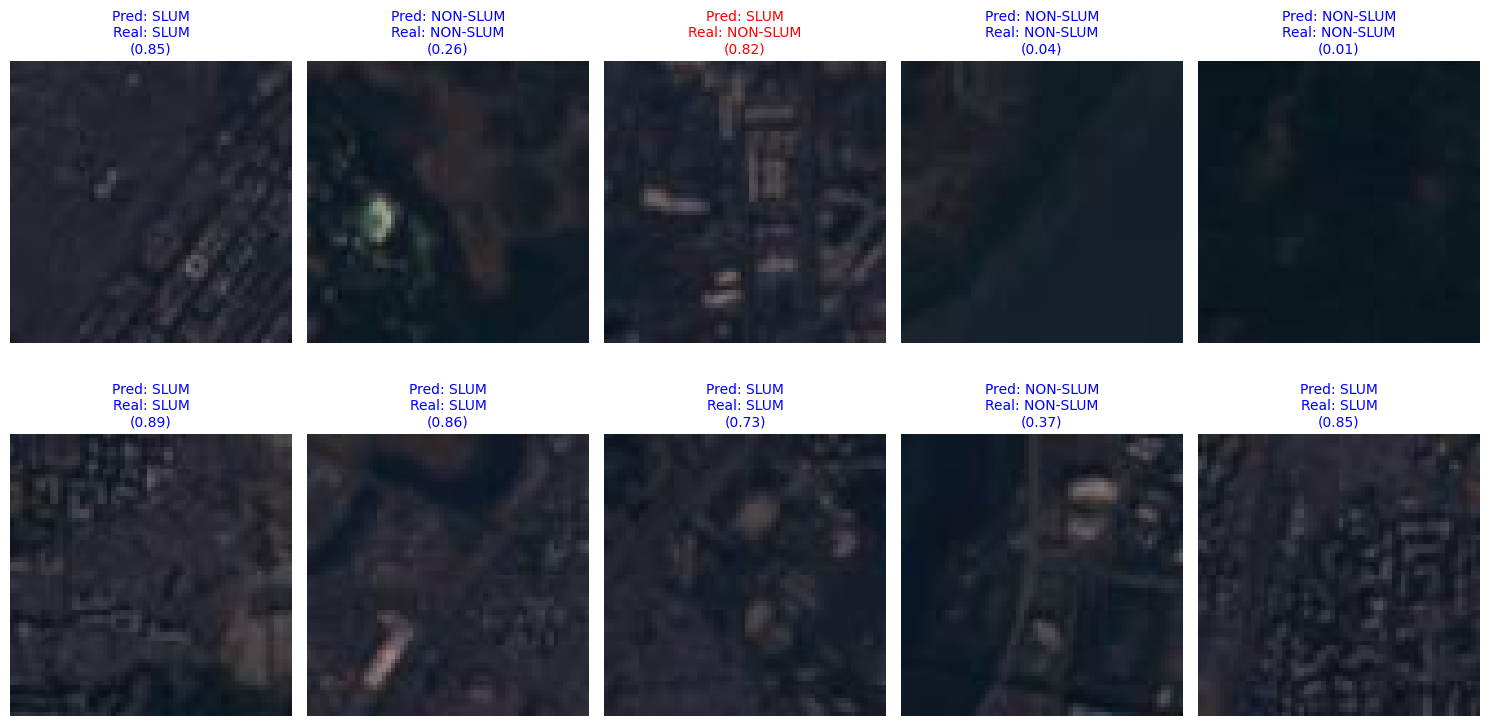

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import glob
import random
import os

# --- CONFIG ---
MODEL_PATH = 'slum_model_final.h5'
SLUM_DIR = 'processed_dataset/slum'
NON_SLUM_DIR = 'processed_dataset/no_slum'
NUM_IMAGES = 10  # How many to test

def visualize_batch():
    if not os.path.exists(MODEL_PATH):
        print("Model not found.")
        return

    model = tf.keras.models.load_model(MODEL_PATH)

    # 1. Get a mix of Slum and Non-Slum files
    slum_files = glob.glob(f"{SLUM_DIR}/*.jpg")
    non_slum_files = glob.glob(f"{NON_SLUM_DIR}/*.jpg")

    # Pick 5 of each (if available)
    batch_files = random.sample(slum_files, min(5, len(slum_files))) + \
                  random.sample(non_slum_files, min(5, len(non_slum_files)))
    random.shuffle(batch_files) # Mix them up

    # 2. Setup the Plot
    plt.figure(figsize=(15, 8))

    for i, file_path in enumerate(batch_files):
        # Load & Preprocess
        img = image.load_img(file_path, target_size=(64, 64))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        score = model.predict(img_array, verbose=0)[0][0]
        label = "SLUM" if score > 0.5 else "NON-SLUM"
        color = 'red' if label == "SLUM" else 'green'

        # Real Label (from folder name)
        real_label = "SLUM" if "slum/s_" in file_path else "NON-SLUM"

        # 3. Display
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.axis('off')

        # Title: PREDICTED (REAL)
        # If prediction matches reality, text is Blue. If wrong, Red.
        title_color = 'blue' if label == real_label else 'red'
        plt.title(f"Pred: {label}\nReal: {real_label}\n({score:.2f})", color=title_color, fontsize=10)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_batch()

Loading model and data...


Found 282 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Running predictions on validation set...
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step
Class Mapping: {'no_slum': 0, 'slum': 1}

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     no_slum       0.99      0.87      0.93       252
        slum       0.46      0.90      0.61        30

    accuracy                           0.88       282
   macro avg       0.72      0.89      0.77       282
weighted avg       0.93      0.88      0.89       282



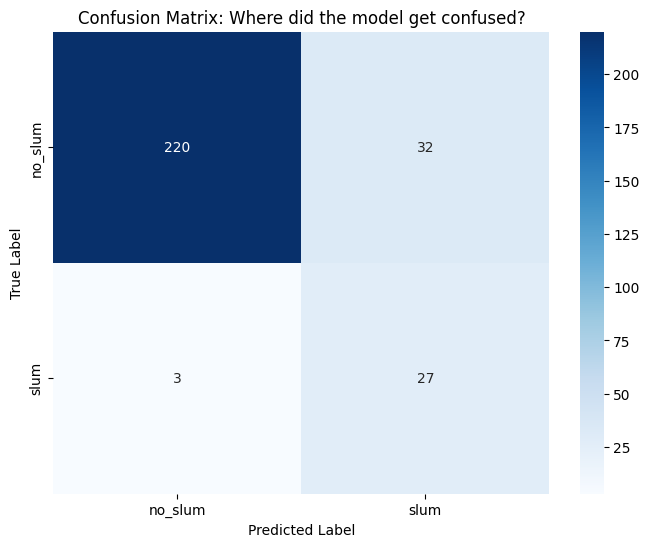

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# --- CONFIG ---
MODEL_PATH = 'slum_model_final.h5'
DATA_DIR = 'processed_dataset'
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

def analyze_performance():
    if not os.path.exists(MODEL_PATH):
        print("Model not found. Run training first!")
        return

    print("Loading model and data...")
    model = tf.keras.models.load_model(MODEL_PATH)

    # 1. Setup Validation Data Generator
    # IMPORTANT: shuffle=False is critical here!
    # We need the predictions to match the order of the true labels.
    test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

    val_ds = test_datagen.flow_from_directory(
        DATA_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        subset='validation',
        shuffle=False  # MUST BE FALSE for metrics to work
    )

    # 2. Run Predictions
    print("\nRunning predictions on validation set...")
    # This gives us probabilities (e.g., 0.85, 0.12)
    predictions_prob = model.predict(val_ds, verbose=1)

    # Convert probabilities to 0 (Non-Slum) or 1 (Slum)
    predictions = (predictions_prob > 0.5).astype(int).flatten()

    # Get the real labels (0 or 1)
    true_labels = val_ds.classes

    # Verify Class Mapping (Usually: no_slum=0, slum=1)
    class_labels = list(val_ds.class_indices.keys())
    print(f"Class Mapping: {val_ds.class_indices}\n")

    # 3. Generate Reports
    print("--- CLASSIFICATION REPORT ---")
    # This prints Precision, Recall, and F1-Score for each class
    report = classification_report(true_labels, predictions, target_names=class_labels)
    print(report)

    # 4. Confusion Matrix
    cm = confusion_matrix(true_labels, predictions)

    # 5. Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Where did the model get confused?')
    plt.show()

if __name__ == "__main__":
    analyze_performance()